In [37]:
import pandas as pd
import pickle
import random
import numpy as np
import os
import itertools
from joblib import Parallel, delayed , parallel_backend
from collections import defaultdict
import math
import torch.nn as nn
import json
import matplotlib.pyplot as plt
import pickle

from Equations_Run_Combo_V_2 import *
from Results_Dists_V_2 import *

import pickle
with open('/Users/cs/Desktop/LSTM_ETF/short_dfs.pkl', 'rb') as f:
    loaded_dfs = pickle.load(f)

with open("/Users/cs/Desktop/LSTM_ETF/lagged_cache.pkl", "rb") as f:
    lagged_cache = pickle.load(f)


#/home/charifslmn/

In [38]:
#                                                       DATA SETS

#### GS data
for i in range(1):   
    with open(f'/Users/cs/Desktop/GS_20_01_to_21_12_chunk_1_22_10percentPOS_Vset_HOD.json', 'r') as f:
        results_GS_ALL = json.load(f)


#### Dist Disc data
with open('/Users/cs/Desktop/top_70_DIST_DISC_GS_20_01_to_21_12_chunk_1_22_10percentPOS_Vset_HOD.json') as f_json:
    results_dist_disc = json.load(f_json)   

    


###### T set with same seed sas val set, neeed sot be organized first 

with open('/Users/cs/Desktop/Tset_NOTsorted_70_models_GS_21_01_to_22_12_DIST_Discovery_10percentPOS_HOD.json') as f:
    results_dist_disc_Tset_NOTsorted_same_seeds = json.load(f)


# ignore = ['val_start_month', 'val_end_month' , 'seed']


##### Organizing the results to have same seeds and combos together --- since params were extracted themselves for GC run simplification 
results_dist_disc_Tset_same_seeds = copy.deepcopy(results_dist_disc_Tset_NOTsorted_same_seeds)

ignore_find_combo = ['val_start_month', 'val_end_month'  ]
### first collect combo_idxs and combo outer info
results_dist_disc_Tset_same_seeds_organized = []
for true in results_dist_disc: ### make sure the combo idx lines up, parallel_backend runs could vary since its the idx when func is called in parallel 
    t_cb_idx = true["combo_index"]

    # same_seed_and_combo = []
    dict_entry = {}
    tt = str({k: v for k, v in true['combo'].items() if k not in ignore_find_combo}).replace(' ', '').replace("'", '').replace('  ', '').replace(',', '')

    for find in results_dist_disc_Tset_same_seeds:

        ff = str({k: v for k, v in find['parameters'].items() if k not in ignore_find_combo}).replace(' ', '').replace("'", '').replace('  ', '').replace(',', '')
        if tt == ff:
            dict_entry["combo_index"] = t_cb_idx
            dict_entry["combo"] = find["parameters"]
            results_dist_disc_Tset_same_seeds_organized.append(dict_entry)
            break
        

ignore_find_seeds = ['val_start_month', 'val_end_month'  , 'seed_num'   ]

### then collect per seed results for each combo , combos are
for entry in results_dist_disc_Tset_same_seeds_organized:
    entry["per_seed_all_results"] = []

    ee = str({k: v for k, v in entry['combo'].items() if k not in ignore_find_seeds}).replace(' ', '').replace("'", '').replace('  ', '').replace(',', '')

    for find in results_dist_disc_Tset_same_seeds:
        ff = str({k: v for k, v in find['parameters'].items() if k not in ignore_find_seeds}).replace(' ', '').replace("'", '').replace('  ', '').replace(',', '')

        if ee == ff:
            seed_entry = {}
            # print(find["parameters"]["seed_num"])
            seed_entry["seed"] = find["parameters"]["seed_num"]
            seed_entry["result_entry"] = find
            entry["per_seed_all_results"].append(seed_entry)

##### Organizing the results to have same seeds and combos together

            


In [39]:
with open('model_based_selection_maps_raw_V_T_data.pkl', 'rb') as f:
    model_based_selection_maps_raw_V_T_data = pickle.load(f)

with open('model_AND_seed_based_selection_maps_raw_V_T_data.pkl', 'rb') as f:
    model_AND_seed_based_selection_maps_raw_V_T_data = pickle.load(f)


model_based_selection_maps_raw_V_T_data.keys()
model_AND_seed_based_selection_maps_raw_V_T_data.keys()

# dict_keys(['Mp_H', 'Mp_M', 'Mp_L', 'DES_Mp_ALL__Rfps_H', 'DES_Mp_ALL__Rfps_L', 'unDES_Mp_ALL__Rfps_H', 
#       'DES_Mp_ALL__R_L', 'DES_Mp_ALL__R_H', 'unDES_Mp_ALL__R_neg'])


# dict_keys(['Sp_H', 'Sp_M', 'Sp_L', 'DES_TH_Sp_ALL__Hb_0fp1tp', 'DES_TH_Sp_ALL__Hb_1fp1tp', 
#       'DES_TH_Sp_ALL__Hb_tp_minus_fp', 'DES_TH_Mp_H__Sp_ALL__Hb_tp_minus_fp'])


dict_keys(['Sp_H', 'Sp_M', 'Sp_L', 'DES_TH_Sp_ALL__Hb_0fp1tp', 'DES_TH_Sp_ALL__Hb_1fp1tp', 'DES_TH_Sp_ALL__Hb_tp_minus_fp', 'DES_TH_Mp_H__Sp_ALL__Hb_tp_minus_fp'])

In [40]:
# dict_keys(['Mp_H', 'Mp_M', 'Mp_L', 'DES_Mp_ALL__Rfps_H', 'DES_Mp_ALL__Rfps_L', 'unDES_Mp_ALL__Rfps_H', 
#       'DES_Mp_ALL__R_L', 'DES_Mp_ALL__R_H', 'unDES_Mp_ALL__R_neg'])
models_data_V_T = {
    "Mp_H" : {"V_set_data" : model_based_selection_maps_raw_V_T_data["Mp_H"]["V_set_data"] , "T_set_data" : model_based_selection_maps_raw_V_T_data["Mp_H"]["T_set_data"]} ,
    "Mp_M" : {"V_set_data" : model_based_selection_maps_raw_V_T_data["Mp_M"]["V_set_data"] , "T_set_data" : model_based_selection_maps_raw_V_T_data["Mp_M"]["T_set_data"]} ,
    "Mp_L" : {"V_set_data" : model_based_selection_maps_raw_V_T_data["Mp_L"]["V_set_data"] , "T_set_data" : model_based_selection_maps_raw_V_T_data["Mp_L"]["T_set_data"]} ,
    ###
    "DES_Mp_ALL__Rfps_H" : {"V_set_data" : model_based_selection_maps_raw_V_T_data["DES_Mp_ALL__Rfps_H"]["V_set_data"] , "T_set_data" : model_based_selection_maps_raw_V_T_data["DES_Mp_ALL__Rfps_H"]["T_set_data"]} ,
    "DES_Mp_ALL__Rfps_L" : {"V_set_data" : model_based_selection_maps_raw_V_T_data["DES_Mp_ALL__Rfps_L"]["V_set_data"] , "T_set_data" : model_based_selection_maps_raw_V_T_data["DES_Mp_ALL__Rfps_L"]["T_set_data"]} ,
    "unDES_Mp_ALL__Rfps_H" : {"V_set_data" : model_based_selection_maps_raw_V_T_data["unDES_Mp_ALL__Rfps_H"]["V_set_data"] , "T_set_data" : model_based_selection_maps_raw_V_T_data["unDES_Mp_ALL__Rfps_H"]["T_set_data"]} ,
    ###
    "DES_Mp_ALL__R_L" : {"V_set_data" : model_based_selection_maps_raw_V_T_data["DES_Mp_ALL__R_L"]["V_set_data"] , "T_set_data" : model_based_selection_maps_raw_V_T_data["DES_Mp_ALL__R_L"]["T_set_data"]} ,
    "DES_Mp_ALL__R_H" : {"V_set_data" : model_based_selection_maps_raw_V_T_data["DES_Mp_ALL__R_H"]["V_set_data"] , "T_set_data" : model_based_selection_maps_raw_V_T_data["DES_Mp_ALL__R_H"]["T_set_data"]} ,
    "unDES_Mp_ALL__R_neg" : {"V_set_data" : model_based_selection_maps_raw_V_T_data["unDES_Mp_ALL__R_neg"]["V_set_data"] , "T_set_data" : model_based_selection_maps_raw_V_T_data["unDES_Mp_ALL__R_neg"]["T_set_data"]}
}



# dict_keys(['Sp_H', 'Sp_M', 'Sp_L', 'DES_TH_Sp_ALL__Hb_0fp1tp', 'DES_TH_Sp_ALL__Hb_1fp1tp', 
#       'DES_TH_Sp_ALL__Hb_tp_minus_fp', 'DES_TH_Mp_H__Sp_ALL__Hb_tp_minus_fp'])
models_AND_seeds_data_V_T = {
    "Sp_H" : {"V_set_data" : model_AND_seed_based_selection_maps_raw_V_T_data["Sp_H"]["V_set_data"] , "T_set_data" : model_AND_seed_based_selection_maps_raw_V_T_data["Sp_H"]["T_set_data"]} ,
    "Sp_M" : {"V_set_data" : model_AND_seed_based_selection_maps_raw_V_T_data["Sp_M"]["V_set_data"] , "T_set_data" : model_AND_seed_based_selection_maps_raw_V_T_data["Sp_M"]["T_set_data"]} ,
    "Sp_L" : {"V_set_data" : model_AND_seed_based_selection_maps_raw_V_T_data["Sp_L"]["V_set_data"] , "T_set_data" : model_AND_seed_based_selection_maps_raw_V_T_data["Sp_L"]["T_set_data"]} ,
    ###
    "DES_TH_Sp_ALL__Hb_0fp1tp" : {"V_set_data" : model_AND_seed_based_selection_maps_raw_V_T_data["DES_TH_Sp_ALL__Hb_0fp1tp"]["V_set_data"] , "T_set_data" : model_AND_seed_based_selection_maps_raw_V_T_data["DES_TH_Sp_ALL__Hb_0fp1tp"]["T_set_data"]} ,
    "DES_TH_Sp_ALL__Hb_1fp1tp" : {"V_set_data" : model_AND_seed_based_selection_maps_raw_V_T_data["DES_TH_Sp_ALL__Hb_1fp1tp"]["V_set_data"] , "T_set_data" : model_AND_seed_based_selection_maps_raw_V_T_data["DES_TH_Sp_ALL__Hb_1fp1tp"]["T_set_data"]} ,
    "DES_TH_Sp_ALL__Hb_tp_minus_fp" : {"V_set_data" : model_AND_seed_based_selection_maps_raw_V_T_data["DES_TH_Sp_ALL__Hb_tp_minus_fp"]["V_set_data"] , "T_set_data" : model_AND_seed_based_selection_maps_raw_V_T_data["DES_TH_Sp_ALL__Hb_tp_minus_fp"]["T_set_data"]} ,
    ###
    "DES_TH_Mp_H__Sp_ALL__Hb_tp_minus_fp" : {"V_set_data" : model_AND_seed_based_selection_maps_raw_V_T_data["DES_TH_Mp_H__Sp_ALL__Hb_tp_minus_fp"]["V_set_data"] , "T_set_data" : model_AND_seed_based_selection_maps_raw_V_T_data["DES_TH_Mp_H__Sp_ALL__Hb_tp_minus_fp"]["T_set_data"]},
}



In [41]:
#####       PURPOSE - THIS IS JSUT FOR TESTING 

def process_and_RETURN_analytics(V_set , T_set , 
                                 
                                 threshold = 0.7, 
                                 min_diff_params = 2,
                                 min_same_up_preds = 0 ,
                                 max_same_up_preds = 1 ,
                                 no_maps_per_group = 10 ,
                                 do_print = True):

    names_all = { 'res_mac_H_val': V_set, 
                'res_mac_H_test': T_set}

    # Define your groups configuration
    groups_config = [
        ("mac",  (-1, 1), 2),
        # ("mac",  (0.1, 0.2), 2),
        # ("mac",  (0.3, 0.5), 2),
        # ("mac",  (-1, 0.3), 3),
        # ("mac",  (0.1, 0.3), 3),
        # ("mac",  (0.3, 0.5), 3)
    ]

    number_realizations = 20

    all_results_regular = []
    all_results_threshold = []

    # random_seeds_seed = 4
    # random.seed(random_seeds_seed)

    sample_size = number_realizations
    seeds = random.sample(range(1, 100000), sample_size)

    for i, seed in zip(range(1, number_realizations), seeds):

        results = process_func_PLUS_return_analytics_THRESH_var_included (
                                            ## new params
                                        threshold = threshold,
                                        names_all = names_all,

                                        #new arams

                                        groups_config = groups_config,
                                        data_type_corr_groups_creation = "V",
                                        data_type_ensemble = "T",
                                        use_threshold_data = False,
                                        seed = None,
                                        no_maps_per_group = no_maps_per_group,
                                        filter_outliers = False ,#### NOTICE NOTICE
                                        use_corr_with_diff_params = False,

                                        min_diff_params = min_diff_params , 
                                        use_spearman_corr = False,
                                        
                                        use_corr_with_same_up_preds = True,
                                        min_same_up_preds = min_same_up_preds,
                                        max_same_up_preds = max_same_up_preds ,


                                        )
        all_results_regular.append(results)


    for i , seed in zip(range(1, number_realizations), seeds):

        results = process_func_PLUS_return_analytics_THRESH_var_included (
                                            ## new params
                                        threshold = threshold,
                                        names_all = names_all,

                                        #new arams

                                        groups_config = groups_config,
                                        data_type_corr_groups_creation = "V",
                                        data_type_ensemble = "T",
                                        use_threshold_data = True,
                                        seed = None,
                                        no_maps_per_group = no_maps_per_group,
                                        filter_outliers = False, #### NOTICE NOTICE
                                        use_corr_with_diff_params = False,

                                        min_diff_params = min_diff_params, 
                                        use_spearman_corr = False,
                                        
                                        use_corr_with_same_up_preds = True,
                                        min_same_up_preds = min_same_up_preds,
                                        max_same_up_preds = max_same_up_preds,

                                        )

        all_results_threshold.append(results)

    all_groups_prec_up_regular = []
    all_groups_total_return_regular = []
    no_up_preds_per_group_regular = []
    all_realizations_unique_actuals_ups_regular = []



            # "Sum of HOD Actual Returns for Up Predictions": HOD_sum_actuals_ups,
            # "Sum of UCO Actual Returns for Up Predictions": UCO_sum_actuals_ups,
            # "Sum of HUC Actual Returns for Up Predictions": HUC_sum_actuals_ups,

    for seed_res in all_results_regular:
        #first set of plots 
        all_groups_total_return_regular.append(seed_res["summary"]["Sum of Actual Returns for Up Predictions"])
        all_groups_prec_up_regular.append(seed_res["summary"]['Prec Up'])
        no_up_preds_per_group_regular.append(seed_res["summary"]['Total Up Predictions'])
        all_realizations_unique_actuals_ups_regular.append(seed_res["summary"]['Unique Actual Returns for Up Predictions'])


    all_realizations_unique_actuals_ups_regular_UNIQUE = set([item for sublist in all_realizations_unique_actuals_ups_regular for item in sublist])
    all_realizations_unique_actuals_ups_regular_UNIQUE_SUM = sum(all_realizations_unique_actuals_ups_regular_UNIQUE)



    all_groups_prec_up_threshold = []
    all_groups_total_return_threshold = []
    no_up_preds_per_group_threshold = []
    all_realizations_unique_actuals_ups_threshold = []



    for seed_res in all_results_threshold:
        all_groups_total_return_threshold.append(seed_res["summary"]["Sum of Actual Returns for Up Predictions"])
        all_groups_prec_up_threshold.append(seed_res["summary"]['Prec Up'])
        no_up_preds_per_group_threshold.append(seed_res["summary"]['Total Up Predictions'])
        all_realizations_unique_actuals_ups_threshold.append(seed_res["summary"]['Unique Actual Returns for Up Predictions'])


    all_realizations_unique_actuals_ups_threshold_UNIQUE = set([item for sublist in all_realizations_unique_actuals_ups_threshold for item in sublist])
    all_realizations_unique_actuals_ups_threshold_UNIQUE_SUM = sum(all_realizations_unique_actuals_ups_threshold_UNIQUE)


    import matplotlib.pyplot as plt

    # List of variable names and titles
    metrics = [
        
        (all_groups_total_return_regular, 'Sum of Actual Returns (Regular)', 'blue'),
        (all_groups_prec_up_regular, 'Precision Up (Regular)', 'blue'),
        (no_up_preds_per_group_regular, 'No Up Predictions (Regular)', 'blue'),

        (all_groups_total_return_threshold, 'Sum of Actual Returns (Threshold)', 'red'),
        (all_groups_prec_up_threshold, 'Precision Up (Threshold)', 'red'),
        (no_up_preds_per_group_threshold, 'No Up Predictions (Threshold)', 'red'),

    ]

    if do_print:
        plt.figure(figsize=(20, 19))

        for i, (var_name, title, color) in enumerate(metrics, 1):

            plt.subplot(6, 3, i)
            data = var_name  # Get the variable by name
            plt.hist(data, bins=15, alpha=0.7, label=title, color=color)
            plt.xlabel('Value')
            plt.ylabel('Frequency')
            plt.title(f'Distribution of {title}')
            plt.legend()

        plt.tight_layout()
        plt.show()


    # print("ALL Realizations Regular Unique Actuals Ups:", all_realizations_unique_actuals_ups_regular_UNIQUE)
    # print("ALL Realizations Regular Unique Actuals Ups Sum:", all_realizations_unique_actuals_ups_regular_UNIQUE_SUM)
    # print("Total Unique Up Preds Regular:", len(all_realizations_unique_actuals_ups_regular_UNIQUE))

    # print("ALL Realizations Threshold Unique Actuals Ups:", all_realizations_unique_actuals_ups_threshold_UNIQUE)
    # print("ALL Realizations Threshold Unique Actuals Ups Sum:", all_realizations_unique_actuals_ups_threshold_UNIQUE_SUM)
    # print("Total Unique Up Preds Threshold:", len(all_realizations_unique_actuals_ups_threshold_UNIQUE))

    output = {
    "all_realizations_unique_actuals_ups_regular_UNIQUE": all_realizations_unique_actuals_ups_regular_UNIQUE,
    "all_realizations_unique_actuals_ups_regular_UNIQUE_SUM": all_realizations_unique_actuals_ups_regular_UNIQUE_SUM,
    "LEN_all_realizations_unique_actuals_ups_regular_UNIQUE": len(all_realizations_unique_actuals_ups_regular_UNIQUE),

    "all_realizations_unique_actuals_ups_threshold_UNIQUE": all_realizations_unique_actuals_ups_threshold_UNIQUE,
    "all_realizations_unique_actuals_ups_threshold_UNIQUE_SUM": all_realizations_unique_actuals_ups_threshold_UNIQUE_SUM,
    "LEN_all_realizations_unique_actuals_ups_threshold_UNIQUE": len(all_realizations_unique_actuals_ups_threshold_UNIQUE)
}

    return output

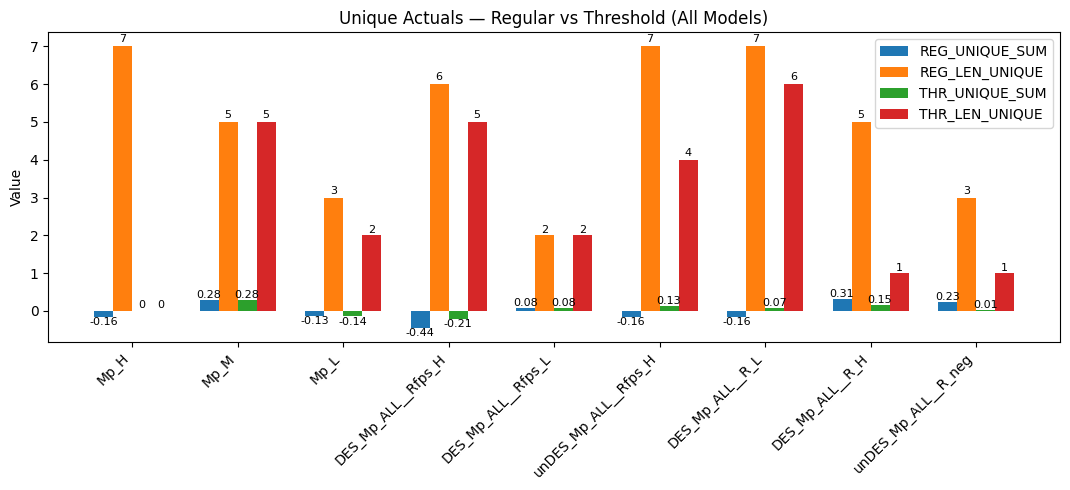

In [42]:
import numpy as np
import matplotlib.pyplot as plt

# 1) Collect metrics for every model key
model_keys = list(models_data_V_T.keys())
metrics_per_model = []  # [REG_UNIQUE_SUM, REG_LEN_UNIQUE, THR_UNIQUE_SUM, THR_LEN_UNIQUE]

for k in model_keys:
    V_set = models_data_V_T[k]["V_set_data"]
    T_set = models_data_V_T[k]["T_set_data"]
    out = process_and_RETURN_analytics(V_set, T_set, do_print=False)

    metrics_per_model.append([
        out["all_realizations_unique_actuals_ups_regular_UNIQUE_SUM"],
        out["LEN_all_realizations_unique_actuals_ups_regular_UNIQUE"],
        out["all_realizations_unique_actuals_ups_threshold_UNIQUE_SUM"],
        out["LEN_all_realizations_unique_actuals_ups_threshold_UNIQUE"],
    ])

metrics = np.array(metrics_per_model, dtype=float)  # shape: (n_models, 4)

# 2) One grouped bar plot: many models on x-axis, 4 bars per model
labels = [
    "REG_UNIQUE_SUM",
    "REG_LEN_UNIQUE",
    "THR_UNIQUE_SUM",
    "THR_LEN_UNIQUE",
]

n_models = len(model_keys)
n_bars = len(labels)
x = np.arange(n_models, dtype=float)
width = 0.18
offsets = np.linspace(-(n_bars-1)/2*width, (n_bars-1)/2*width, n_bars)

fig, ax = plt.subplots(figsize=(max(8, n_models * 1.2), 5))

bars = []
for i in range(n_bars):
    b = ax.bar(x + offsets[i], metrics[:, i], width=width, label=labels[i])
    bars.append(b)

ax.set_xticks(x)
ax.set_xticklabels(model_keys, rotation=45, ha='right')
ax.set_ylabel("Value")
ax.set_title("Unique Actuals — Regular vs Threshold (All Models)")
ax.legend(loc="best")

# 3) Write values on the bars for clarity (different scales handled)
for b in bars:
    for rect in b:
        h = rect.get_height()
        x_pos = rect.get_x() + rect.get_width() / 2
        offset = 0.01 * (abs(h) if abs(h) > 1 else 1)
        y_pos = h + (offset if h >= 0 else -offset)
        va = "bottom" if h >= 0 else "top"
        txt = f"{int(h):,}" if float(h).is_integer() else f"{h:,.2f}"
        ax.text(x_pos, y_pos, txt, ha="center", va=va, fontsize=8)

fig.tight_layout()
plt.show()


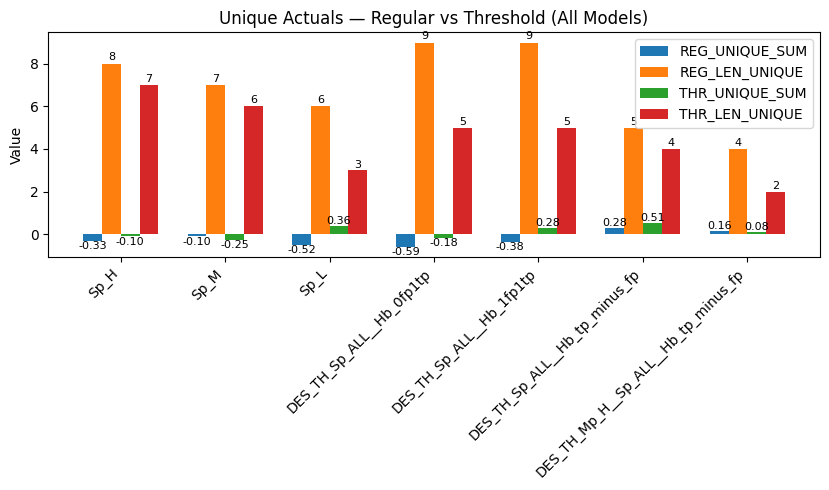

In [43]:
import numpy as np
import matplotlib.pyplot as plt

# 1) Collect metrics for every model key
model_keys = list(models_AND_seeds_data_V_T.keys())
metrics_per_model = []  # [REG_UNIQUE_SUM, REG_LEN_UNIQUE, THR_UNIQUE_SUM, THR_LEN_UNIQUE]

for k in model_keys:
    V_set = models_AND_seeds_data_V_T[k]["V_set_data"]
    T_set = models_AND_seeds_data_V_T[k]["T_set_data"]
    out = process_and_RETURN_analytics(V_set, T_set, do_print=False)

    metrics_per_model.append([
        out["all_realizations_unique_actuals_ups_regular_UNIQUE_SUM"],
        out["LEN_all_realizations_unique_actuals_ups_regular_UNIQUE"],
        out["all_realizations_unique_actuals_ups_threshold_UNIQUE_SUM"],
        out["LEN_all_realizations_unique_actuals_ups_threshold_UNIQUE"],
    ])

metrics = np.array(metrics_per_model, dtype=float)  # shape: (n_models, 4)

# 2) One grouped bar plot: many models on x-axis, 4 bars per model
labels = [
    "REG_UNIQUE_SUM",
    "REG_LEN_UNIQUE",
    "THR_UNIQUE_SUM",
    "THR_LEN_UNIQUE",
]

n_models = len(model_keys)
n_bars = len(labels)
x = np.arange(n_models, dtype=float)
width = 0.18
offsets = np.linspace(-(n_bars-1)/2*width, (n_bars-1)/2*width, n_bars)

fig, ax = plt.subplots(figsize=(max(8, n_models * 1.2), 5))

bars = []
for i in range(n_bars):
    b = ax.bar(x + offsets[i], metrics[:, i], width=width, label=labels[i])
    bars.append(b)

ax.set_xticks(x)
ax.set_xticklabels(model_keys, rotation=45, ha='right')
ax.set_ylabel("Value")
ax.set_title("Unique Actuals — Regular vs Threshold (All Models)")
ax.legend(loc="best")

# 3) Write values on the bars for clarity (different scales handled)
for b in bars:
    for rect in b:
        h = rect.get_height()
        x_pos = rect.get_x() + rect.get_width() / 2
        offset = 0.01 * (abs(h) if abs(h) > 1 else 1)
        y_pos = h + (offset if h >= 0 else -offset)
        va = "bottom" if h >= 0 else "top"
        txt = f"{int(h):,}" if float(h).is_integer() else f"{h:,.2f}"
        ax.text(x_pos, y_pos, txt, ha="center", va=va, fontsize=8)

fig.tight_layout()
plt.show()


In [44]:
from Functions_1_Initial_GS_and_Dist_Analytics_HOD_20_01_21_12 import *

### NOTE consider changing this os that the function chooses the max number of midels possible , this should imporve the resutls in general since 
### seeds of the same model are generally more correalted --- this can also be tested but i am pretty positive this is the case (ran short tests)

### NOTE for now since we want to test the params for model slection , it may be better to keep it as is for standardization

def collect_V_T_set_FULLraw_data(models_selected, results_dist_disc, results_dist_disc_Tset_same_seeds_organized):
    T_set_data = [] 
    V_set_data = []

    # select 5 models at random from the selected models
    models_RAND = random.sample(models_selected, min(15, len(models_selected)))

    for model_entry in models_RAND:
        model_seeds = []
        ff_combo_idx = model_entry['combo_index']
        for seed_entry in model_entry['selected_seeds']:
            seed_num = seed_entry['seed_num']
            model_seeds.append(seed_num)

        ##### Find randomly chosen seeds in the V and T raw data 
        for raw_data_entry_V in results_dist_disc:
            V_combo_idx = raw_data_entry_V["combo_index"]
            if ff_combo_idx == V_combo_idx:
                rand_chosen_seeds = random.sample(model_seeds, min(1, len(model_seeds)))
                for seed_chosen in rand_chosen_seeds:
                    for seed_raw in raw_data_entry_V['per_seed_all_results']:
                        if seed_raw['seed'] == seed_chosen:
                            V_set_data.append(seed_raw['result_entry'])

        for raw_data_entry_T in results_dist_disc_Tset_same_seeds_organized:
            T_combo_idx = raw_data_entry_T["combo_index"]
            if ff_combo_idx == T_combo_idx:
                for seed_chosen in rand_chosen_seeds:
                    for seed_raw in raw_data_entry_T['per_seed_all_results']:
                        if seed_raw['seed'] == seed_chosen:
                            T_set_data.append(seed_raw['result_entry'])

    return {"V_set_data": V_set_data, "T_set_data": T_set_data}


                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            

# res = collect_V_T_set_FULLraw_data(Mp_H__param_map_models, results_dist_disc, results_dist_disc_Tset_same_seeds_organized)
# V_set_data = res["V_set_data"] ; T_set_data = res["T_set_data"]
# print(len(V_set_data)) ; print(len(T_set_data))  


In [20]:
RR = {   
                             "mean_precision_range" : (5, 100),"max_zero_precision_seeds" : 70,
                             "max_FP_severe_ratio_FPs" : None, "min_FP_severe_ratio_FPs" : None,         
                             "min_ratio_difference" : None, "max_ratio_difference" : None,

                             "seed_precision_range" : (1, 40) , 
                             "seed_min_TPminusFP_greaterEqual" : None , 
                             "max_seed_severe_FPs_high_bracket" : None , 
                             "min_seed_TPs_high_bracket" : None ,

                             "seed_recall_range" : (0, 100), "min_seeds_per_model" : 1,
                             "max_models_to_return" : 70, "max_FP_severe_ratio_FPs_andTPs" : None, 
                             "min_FP_severe_ratio_FPs_andTPs" : None ,"random_seed" : None 

                               }
models = select_models_by_criteria(results_dist_disc, **RR)

res = collect_V_T_set_FULLraw_data(models, results_dist_disc, results_dist_disc_Tset_same_seeds_organized)
V = res["V_set_data"] ; T = res["T_set_data"]

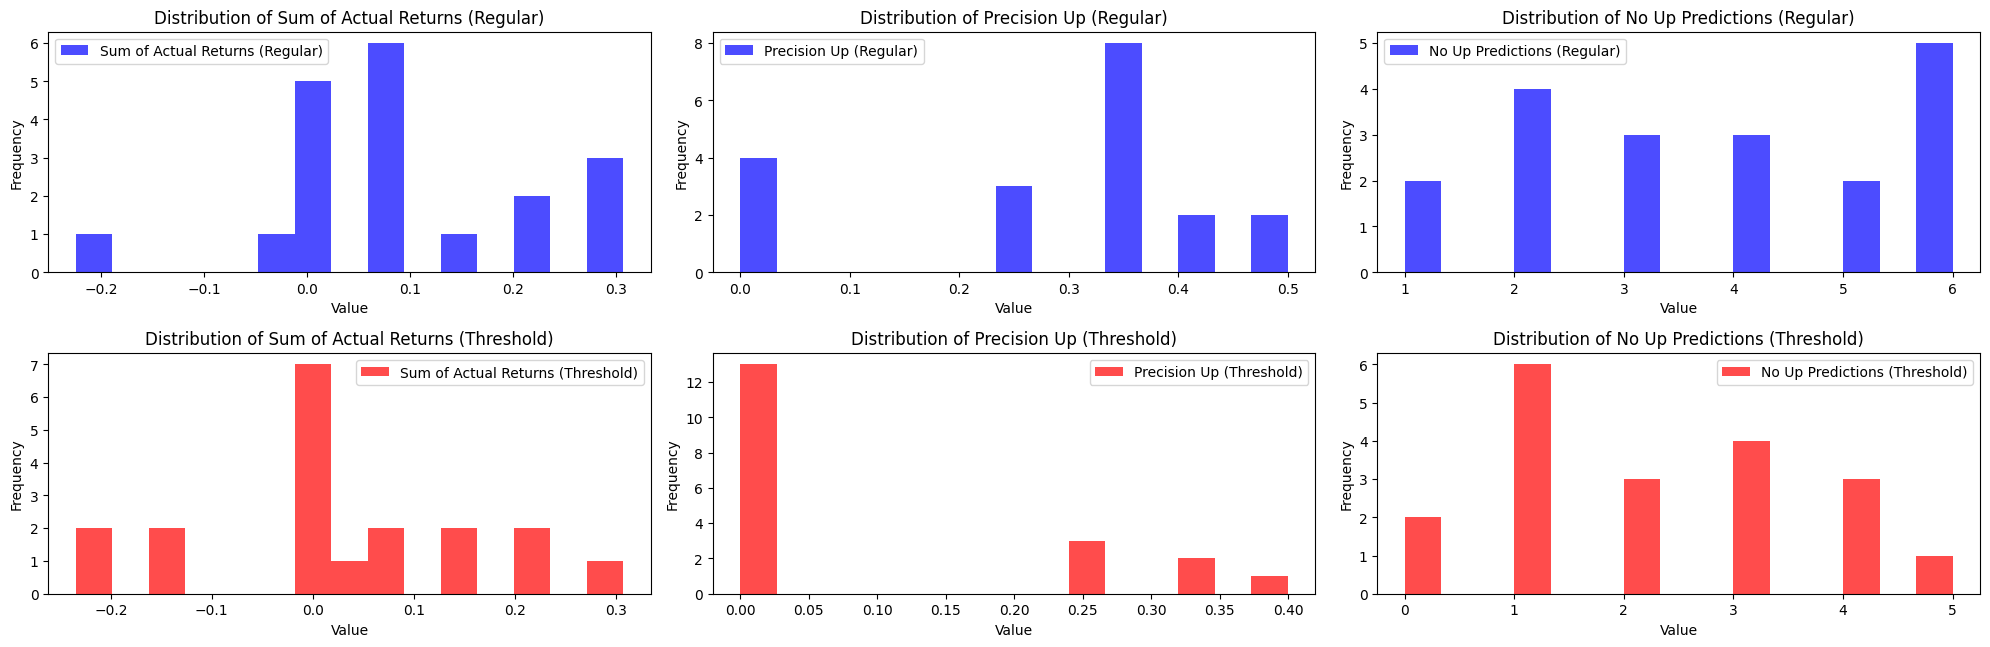

ALL Realizations Regular Unique Actuals Ups: {0.01014370245139462, -0.23493562231759657, 0.06672678088367912, 0.28744769874477005, 0.15017414464249113, -0.20685732856678574}
ALL Realizations Regular Unique Actuals Ups Sum: 0.0726993758379526
Total Unique Up Preds Regular: 6
ALL Realizations Threshold Unique Actuals Ups: {-0.23493562231759657, 0.06672678088367912, 0.28744769874477005, 0.15017414464249113, 0.01014370245139462, -0.20685732856678574}
ALL Realizations Threshold Unique Actuals Ups Sum: 0.0726993758379526
Total Unique Up Preds Threshold: 6


{'all_realizations_unique_actuals_ups_regular_UNIQUE': {-0.23493562231759657,
  -0.20685732856678574,
  0.01014370245139462,
  0.06672678088367912,
  0.15017414464249113,
  0.28744769874477005},
 'all_realizations_unique_actuals_ups_regular_UNIQUE_SUM': 0.0726993758379526,
 'LEN_all_realizations_unique_actuals_ups_regular_UNIQUE': 6,
 'all_realizations_unique_actuals_ups_threshold_UNIQUE': {-0.23493562231759657,
  -0.20685732856678574,
  0.01014370245139462,
  0.06672678088367912,
  0.15017414464249113,
  0.28744769874477005},
 'all_realizations_unique_actuals_ups_threshold_UNIQUE_SUM': 0.0726993758379526,
 'LEN_all_realizations_unique_actuals_ups_threshold_UNIQUE': 6}

In [10]:

def process_and_RETURN_analytics(V_set , T_set , 
                                 
                                 threshold = 0.7, 
                                 min_diff_params = 2,
                                 min_same_up_preds = 0 ,
                                 max_same_up_preds = 1 ,
                                 no_maps_per_group = 10 ,
                                 do_print = True):

    names_all = { 'res_mac_H_val': V_set, 
                'res_mac_H_test': T_set}

    # Define your groups configuration
    groups_config = [
        ("mac",  (-1, 1), 2),
        # ("mac",  (0.1, 0.2), 2),
        # ("mac",  (0.3, 0.5), 2),
        # ("mac",  (-1, 0.3), 3),
        # ("mac",  (0.1, 0.3), 3),
        # ("mac",  (0.3, 0.5), 3)
    ]

    number_realizations = 20

    all_results_regular = []
    all_results_threshold = []

    # random_seeds_seed = 4
    # random.seed(random_seeds_seed)

    sample_size = number_realizations
    seeds = random.sample(range(1, 100000), sample_size)

    for i, seed in zip(range(1, number_realizations), seeds):

        results = process_func_PLUS_return_analytics_THRESH_var_included (
                                            ## new params
                                        threshold = threshold,
                                        names_all = names_all,

                                        #new arams

                                        groups_config = groups_config,
                                        data_type_corr_groups_creation = "V",
                                        data_type_ensemble = "T",
                                        use_threshold_data = False,
                                        seed = None,
                                        no_maps_per_group = no_maps_per_group,
                                        filter_outliers = False ,#### NOTICE NOTICE
                                        use_corr_with_diff_params = False,

                                        min_diff_params = min_diff_params , 
                                        use_spearman_corr = False,
                                        
                                        use_corr_with_same_up_preds = True,
                                        min_same_up_preds = min_same_up_preds,
                                        max_same_up_preds = max_same_up_preds ,


                                        )
        all_results_regular.append(results)


    for i , seed in zip(range(1, number_realizations), seeds):

        results = process_func_PLUS_return_analytics_THRESH_var_included (
                                            ## new params
                                        threshold = threshold,
                                        names_all = names_all,

                                        #new arams

                                        groups_config = groups_config,
                                        data_type_corr_groups_creation = "V",
                                        data_type_ensemble = "T",
                                        use_threshold_data = True,
                                        seed = None,
                                        no_maps_per_group = no_maps_per_group,
                                        filter_outliers = False, #### NOTICE NOTICE
                                        use_corr_with_diff_params = False,

                                        min_diff_params = min_diff_params, 
                                        use_spearman_corr = False,
                                        
                                        use_corr_with_same_up_preds = True,
                                        min_same_up_preds = min_same_up_preds,
                                        max_same_up_preds = max_same_up_preds,

                                        )

        all_results_threshold.append(results)

    all_groups_prec_up_regular = []
    all_groups_total_return_regular = []
    no_up_preds_per_group_regular = []
    all_realizations_unique_actuals_ups_regular = []



            # "Sum of HOD Actual Returns for Up Predictions": HOD_sum_actuals_ups,
            # "Sum of UCO Actual Returns for Up Predictions": UCO_sum_actuals_ups,
            # "Sum of HUC Actual Returns for Up Predictions": HUC_sum_actuals_ups,

    for seed_res in all_results_regular:
        #first set of plots 
        all_groups_total_return_regular.append(seed_res["summary"]["Sum of Actual Returns for Up Predictions"])
        all_groups_prec_up_regular.append(seed_res["summary"]['Prec Up'])
        no_up_preds_per_group_regular.append(seed_res["summary"]['Total Up Predictions'])
        all_realizations_unique_actuals_ups_regular.append(seed_res["summary"]['Unique Actual Returns for Up Predictions'])


    all_realizations_unique_actuals_ups_regular_UNIQUE = set([item for sublist in all_realizations_unique_actuals_ups_regular for item in sublist])
    all_realizations_unique_actuals_ups_regular_UNIQUE_SUM = sum(all_realizations_unique_actuals_ups_regular_UNIQUE)



    all_groups_prec_up_threshold = []
    all_groups_total_return_threshold = []
    no_up_preds_per_group_threshold = []
    all_realizations_unique_actuals_ups_threshold = []



    for seed_res in all_results_threshold:
        all_groups_total_return_threshold.append(seed_res["summary"]["Sum of Actual Returns for Up Predictions"])
        all_groups_prec_up_threshold.append(seed_res["summary"]['Prec Up'])
        no_up_preds_per_group_threshold.append(seed_res["summary"]['Total Up Predictions'])
        all_realizations_unique_actuals_ups_threshold.append(seed_res["summary"]['Unique Actual Returns for Up Predictions'])


    all_realizations_unique_actuals_ups_threshold_UNIQUE = set([item for sublist in all_realizations_unique_actuals_ups_threshold for item in sublist])
    all_realizations_unique_actuals_ups_threshold_UNIQUE_SUM = sum(all_realizations_unique_actuals_ups_threshold_UNIQUE)


    import matplotlib.pyplot as plt

    # List of variable names and titles
    metrics = [
        
        (all_groups_total_return_regular, 'Sum of Actual Returns (Regular)', 'blue'),
        (all_groups_prec_up_regular, 'Precision Up (Regular)', 'blue'),
        (no_up_preds_per_group_regular, 'No Up Predictions (Regular)', 'blue'),

        (all_groups_total_return_threshold, 'Sum of Actual Returns (Threshold)', 'red'),
        (all_groups_prec_up_threshold, 'Precision Up (Threshold)', 'red'),
        (no_up_preds_per_group_threshold, 'No Up Predictions (Threshold)', 'red'),

    ]

    if do_print:
        plt.figure(figsize=(20, 19))

        for i, (var_name, title, color) in enumerate(metrics, 1):

            plt.subplot(6, 3, i)
            data = var_name  # Get the variable by name
            plt.hist(data, bins=15, alpha=0.7, label=title, color=color)
            plt.xlabel('Value')
            plt.ylabel('Frequency')
            plt.title(f'Distribution of {title}')
            plt.legend()

        plt.tight_layout()
        plt.show()


    print("ALL Realizations Regular Unique Actuals Ups:", all_realizations_unique_actuals_ups_regular_UNIQUE)
    print("ALL Realizations Regular Unique Actuals Ups Sum:", all_realizations_unique_actuals_ups_regular_UNIQUE_SUM)
    print("Total Unique Up Preds Regular:", len(all_realizations_unique_actuals_ups_regular_UNIQUE))

    print("ALL Realizations Threshold Unique Actuals Ups:", all_realizations_unique_actuals_ups_threshold_UNIQUE)
    print("ALL Realizations Threshold Unique Actuals Ups Sum:", all_realizations_unique_actuals_ups_threshold_UNIQUE_SUM)
    print("Total Unique Up Preds Threshold:", len(all_realizations_unique_actuals_ups_threshold_UNIQUE))

    output = {
    "all_realizations_unique_actuals_ups_regular_UNIQUE": all_realizations_unique_actuals_ups_regular_UNIQUE,
    "all_realizations_unique_actuals_ups_regular_UNIQUE_SUM": all_realizations_unique_actuals_ups_regular_UNIQUE_SUM,
    "LEN_all_realizations_unique_actuals_ups_regular_UNIQUE": len(all_realizations_unique_actuals_ups_regular_UNIQUE),

    "all_realizations_unique_actuals_ups_threshold_UNIQUE": all_realizations_unique_actuals_ups_threshold_UNIQUE,
    "all_realizations_unique_actuals_ups_threshold_UNIQUE_SUM": all_realizations_unique_actuals_ups_threshold_UNIQUE_SUM,
    "LEN_all_realizations_unique_actuals_ups_threshold_UNIQUE": len(all_realizations_unique_actuals_ups_threshold_UNIQUE)
}

    return output



process_and_RETURN_analytics(V_set = V , T_set = T , 
                                 

                                 do_print = True)